# Program - cn_pt

**Purpose**

Read TaiESM hindcast simulation data. Given a variable and lat/lon, plot time-pressure cross-section.

**Content**
- Read TaiESM hindcast data at a grid point (lat, lon)
- Interpolate the data on the same pressure levels
- Set tick marks for time
- Adjust contour levels and color bar according to the variables
- Make cn_pt plots, using either contourf (smoothed coutour) or pcolormesh (pixeled contour)

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 

**Reference program:**



In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc
#import read_data as read_data   ## on GFDL PP/AN
import read_data_big as read_data    ## on my Mac

#--- silence dask large chunk and silence the warning.
import dask
dask.config.set(**{'array.slicing.split_large_chunks': False})

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


# Functions

## ----- read data functions -----

## select_region_ds

In [2]:
##################
##################
##################
def select_region_ds(ds,
                  region="lat_lon",
                  lat=None, lon=None, 
                 ):

    func_name = "select_ds_region"
    
    #--- given the lat/lon range of a region
    if (region == "NE_CA"):
        #lowerlon=235; upperlon=245; lowerlat=28; upperlat=35
        lowerlon=225; upperlon=250; lowerlat=24; upperlat=40

    elif (region == "DYCOMS"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  236.5  # 123.5W
        upperlon =  240    # 120W

    elif (region == "lat_lon"): 
        if lat is None or lon is None:
            error_msg = f"ERROR: function [{func_name}] needs lat [{lat}] and lon [{lon}] when region='lat_lon'"
            raise KeyError(error_msg)
    
    else:
        lowerlon=-1000; upperlon=1000; lowerlat=-1000; upperlat=1000

    #--- select for in the given region
    if (region == "lat_lon"):
        lat_index, lon_index = get_lat_lon_indexes(ds, lat, lon)
        ds_region = ds.isel(lat=lat_index, lon=lon_index)

    else:
        lon_slice = slice(lowerlon, upperlon)
        lat_slice = slice(lowerlat, upperlat)
        ds_region = ds.sel(lat=lat_slice, lon=lon_slice)
    
    return ds_region

##################
##################
##################
def get_lat_lon_indexes(ds, lat, lon):
    lat_index = abs(ds['lat'] - lat).argmin().item()
    lon_index = abs(ds['lon'] - lon).argmin().item()

    return lat_index, lon_index

#-----------
# do_test
#-----------

do_test="111"
#do_test=False

if (do_test == "111"):
    choice = "custom_Ttend_3hr"
    icdate = "20010710"
    ds1 = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=5)
    
    lat=31.5 ; lon=236.5
    
    ds1_region = select_region_ds(ds1, region="lat_lon", lat=lat, lon=lon)

#ds1_region

## read_hindcast_icdate_lat_lon

In [3]:
def read_hindcast_icdate_lat_lon(icdate, 
    lat=31.5, lon=236.5,
    ):

    file_dates = 5

    #--- read datasets
    choice = "custom_Ttend_3hr"
    ds_Ttend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    choice = "custom_state_3hr"
    ds_state = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    choice = "custom_Qtend_3hr"
    ds_Qtend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    #--- diagnose variables in all ds
    yhc.diagnose_var(ds_state, ["play"])
    yhc.diagnose_var(ds_Ttend, ["DT_SUM_PHYS"])
    yhc.diagnose_var(ds_Qtend, ["DQV_SUM_PHYS", "DQL_SUM_PHYS"])

    #--- get data at the given lat/lon
    ds_Ttend_latlon = select_region_ds(ds_Ttend, region="lat_lon", lat=lat, lon=lon)
    ds_Qtend_latlon = select_region_ds(ds_Qtend, region="lat_lon", lat=lat, lon=lon)
    ds_state_latlon = select_region_ds(ds_state, region="lat_lon", lat=lat, lon=lon)

    return ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon

#-----------
# do_test
#-----------

do_test="112"
#do_test=False

if (do_test == "111"):
    icdate = "20010710"
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate)

#ds_state_latlon
#ds_Ttend_latlon
#ds_Qtend_latlon

## ----- cn_pt -----

## get_plot_settings

In [4]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

################
################
################
def get_plot_settings(var: xr.DataArray, var_name: str):
    """
    Get plot settings (cmap, levels, long_name, units, and cbar_label) for a given variable.

    Parameters:
    - var: xarray.DataArray
        The variable to be plotted.
    - var_name: str
        The name of the variable.

    Returns:
    - settings: dict
        A dictionary with plot settings for the given variable.
    """
    # Default settings in case attributes are missing
    default_settings = {
        "cmap": "viridis",
        "levels": None,  # Will be determined dynamically if possible
        "norm": None, 
        "norm_option": None, 
        "long_name": var_name,  # Use var_name if long_name is missing
        "units": "Unknown Units",
        "cbar_label": f"{var_name} (Unknown Units)"
    }

    # Predefined variable settings (can be extended)
    ttend_min = -30 ; ttend_max = 20 ; ttend_num_levels = 11
    variable_settings = {
        "TTEND_TOT": {"cmap": "RdBu_r", 
                      #"levels":np.linspace(ttend_min, ttend_max, ttend_num_levels) ,
                      #"norm": mcolors.TwoSlopeNorm(vmin=ttend_min, vcenter=0, vmax=ttend_max),
                      "norm_option" : "auto", 
                     },
        "QVTEND_TOT": {"cmap": "BrBG", 
                       "norm_option" : "auto", 
                      },
        "QLTEND_TOT": {"cmap": "BrBG", 
                       "norm_option" : "auto", 
                      },
        "T": {"cmap": "coolwarm"},
        "Q": {"cmap": "YlGnBu"},
        "CLDLIQ": {"cmap": "viridis"},
        "P": {"cmap": "RdBu"}
    }
    
    # Extract attributes
    long_name = var.attrs.get("long_name", default_settings["long_name"])
    units = var.attrs.get("units", default_settings["units"])

    # Determone cmap, levels, and norm
    cmap, levels, norm = get_cmap_levels_norm (var_name, variable_settings, default_settings, var)
    
    if var_name in ["MPDT", "MACPDT", "DTV", "DT_SUM_PHYS", "DTCORE", "PTTEND"]:
        cmap, levels, norm = get_cmap_levels_norm ("TTEND_TOT", variable_settings, default_settings, var)  
    elif var_name in ["PTEQ", "MACPDQ", "MPDQ", "VD01", "DQVCORE", "DQV_SUM_PHYS"]:
        cmap, levels, norm = get_cmap_levels_norm ("QVTEND_TOT", variable_settings, default_settings, var)
    elif var_name in ["PTECLDLIQ", "MACPDLIQ", "MPDLIQ", "VDCLDLIQ", "DQLCORE", "DQL_SUM_PHYS"]:
        cmap, levels, norm = get_cmap_levels_norm ("QLTEND_TOT", variable_settings, default_settings, var)
    
    # Construct colorbar label
    cbar_label = f"{long_name} ({units})"

    return {
        "norm":norm, 
        ###
        "cmap": cmap,
        "levels": levels,
        "long_name": long_name,
        "units": units,
        "cbar_label": cbar_label
    }

################
################
################
def get_nice_contour_levels(var_data, num_levels=15):
    if np.issubdtype(var_data.dtype, np.number):  # Ensure it's numeric
        vmin, vmax = np.nanmin(var_data), np.nanmax(var_data)

        # Round vmin/vmax based on magnitude
        magnitude = 10 ** np.floor(np.log10(vmax - vmin))  # Order of magnitude
        vmin = np.floor(vmin / magnitude) * magnitude
        vmax = np.ceil(vmax / magnitude) * magnitude

        # Use MaxNLocator to find nice levels
        locator = mticker.MaxNLocator(nbins=num_levels - 1, steps=[1, 2, 2.5, 5, 10])
        levels = locator.tick_values(vmin, vmax)
    else:
        levels = default_settings["levels"]  # Use default if non-numeric

    return levels

################
################
################
def get_cmap_levels_norm(var_name, variable_settings, default_settings, var=None):
    """
    Retrieve colormap, contour levels, and norm settings for a given variable.

    Parameters:
        var_name (str): Name of the variable.
        variable_settings (dict): Dictionary with variable-specific settings.
        default_settings (dict): Dictionary with default settings.
        var (xarray.DataArray or numpy array, optional): Data array for computing levels dynamically.

    Returns:
        tuple: (cmap, levels, norm)
    """
    # Determine colormap
    cmap = variable_settings.get(var_name, {}).get("cmap", default_settings["cmap"])
    
    # Determine contour levels
    levels = variable_settings.get(var_name, {}).get("levels", default_settings["levels"])
    if levels is None and var is not None:
        var_data = var.values
        levels = get_nice_contour_levels(var_data)

    # Determine norm
    norm_option = variable_settings.get(var_name, {}).get("norm_option", default_settings["norm_option"])
    if norm_option == "auto":
        norm = mcolors.TwoSlopeNorm(vmin=np.min(levels), vcenter=0, vmax=np.max(levels))
    else:
        norm = variable_settings.get(var_name, {}).get("norm", default_settings["norm"])

    return cmap, levels, norm

## get_var_data_play

In [5]:
#ds_Ttend_latlon

In [6]:
def get_var_data_play(ds: xr.Dataset, play, var_name: str, pmin=800, pmax=1100):
    
    var_da = ds[var_name]  # Get the variable data as a numpy array
    var_da = yhc.unit_convert(var_da)  # convert units

    # select pressure range
    var_da_lev = var_da.sel(lev=(var_da.lev >= pmin) & (var_da.lev <= pmax))
    play_lev   = play.sel(lev=(play.lev >= pmin) & (play.lev <= pmax))

    settings = get_plot_settings(var_da_lev, var_name)

    return var_da_lev, play_lev, settings

#-----------
# do_test
#-----------

do_test="111"
if (do_test == "111"):
    icdate = "20010710"
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate)

    play_pt = ds_state_latlon['play']
    pmin=100 ; pmax=1100
    
    #var_name = "TTEND_TOT"
    #var_da_lev, play_lev, settings = get_var_data_play (ds_Ttend_latlon, play_pt, var_name=var_name)

    #var_name = "T"
    #var_da_lev, play_lev, settings = get_var_data_play (ds_state_latlon, play_pt, var_name=var_name, pmin=pmin, pmax=pmax)

    var_name = "QVTEND_TOT"
    var_da_lev, play_lev, settings = get_var_data_play (ds_Qtend_latlon, play_pt, var_name=var_name)
    
#print(settings)
#var_da_lev
#play_lev

## plot_time_lev_contour

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cftime
from scipy import interpolate

def plot_time_lev_contour(ax, ds, var_name, play_pt, time_interval_hours=12, minor_time_interval_hours=3, title=None):
    """
    Plot a time vs. pressure contour plot for a given variable in the dataset.

    Parameters:
    - ax: matplotlib Axes object
        The axes on which to plot.
    - ds: xarray.Dataset
        The dataset containing the variable to plot.
    - var_name: str
        The variable name to plot (e.g., "T", "Q", "P").
    - play: xarray.DataArray
        The pressure levels corresponding to the data.
    - time_interval_hours: int, optional
        The interval for the x-axis ticks (default is 12 hours).
    - minor_time_interval_hours: int, optional
        The interval for minor ticks on the x-axis (default is 6 hours).
    - title: str, optional
        The title for the plot (default is None).
    """
    # Get da & plot settings for the variable
    #var_da, settings = get_var_data (ds, var_name=var_name)
    var_da, play, settings = get_var_data_play (ds, play_pt, var_name=var_name)

    # Get plot settings for the variable
    cmap = settings["cmap"]
    levels = settings["levels"]
    long_name = settings["long_name"]
    units = settings["units"]
    cbar_label = settings["cbar_label"]  # This now contains long_name (units)
    norm = settings["norm"]
    
    # Extract lat and lon directly from ds and format to two decimal places
    lat = var_da.lat.values
    lon = var_da.lon.values
    lat_str = f"{lat:.2f}"
    lon_str = f"{lon:.2f}"

    # Create a title with lat/lon if not provided
    if title is None:
        title = f"lat={lat_str}, lon={lon_str}"

    # Interpolate variable to the same pressure level as play[0]
    play_0 = play[0, :]  # Take the pressure levels at the first time step (1D)
    var_data = var_da.values  # Get the variable data as a numpy array

    # Create interpolation function for each time step
    interpolated_data = []
    for t in range(len(ds["time"].values)):
        interp_func = interpolate.interp1d(play[t, :], var_data[t, :], kind="linear", fill_value="extrapolate")
        interpolated_data.append(interp_func(play_0))  # Interpolate to play_0 levels

    # Stack interpolated data into a 2D array (time x lev)
    interpolated_data = np.stack(interpolated_data)

    # Select the first level from play (assuming you're interested in the first pressure level)
    play_1d = play_0  # Using play_0 as the pressure levels for the contour plot

    # Convert time to numeric values (0 to len(time))
    time_numeric = np.arange(len(ds["time"].values))

    # Plot the contour
    if (norm is not None):
        cont = ax.contourf(time_numeric, play_1d, interpolated_data.T, levels=levels, cmap=cmap, norm=norm)
    else:
        cont = ax.contourf(time_numeric, play_1d, interpolated_data.T, levels=levels, cmap=cmap)

    #cont = ax.pcolormesh(time_numeric, play_1d, interpolated_data.T, levels=levels, cmap=cmap)
    
    # Set the title with adjusted position (a bit higher)
    ax.set_title(title, pad=20)

    # Set x-axis and y-axis labels
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Pressure (hPa)')

    # Reverse the y-axis so that 1000 hPa will be at the bottom
    ax.invert_yaxis()

    # Set the x-axis ticks and labels for time
    time_ticks = np.arange(0, len(time_numeric), time_interval_hours)
    ax.set_xticks(time_ticks)
    
    # Assign the x-axis labels from cftime (for time values)
    time_labels = [t.strftime('%m%d_%H') for t in ds["time"].isel(time=time_ticks).values]
    ax.set_xticklabels(time_labels)

    # Add grid lines    
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

    # Add minor ticks
    ax.minorticks_on()
    ax.tick_params(which='minor', length=4, color='gray')
    minor_time_ticks = np.arange(0, len(time_numeric), minor_time_interval_hours)
    ax.set_xticks(minor_time_ticks, minor=True)

    # Add colorbar
    cbar = plt.colorbar(cont, ax=ax)
    cbar.set_label(cbar_label)

    # Add long_name in the upper left and units in the upper right
    #ax.text(0, 1.05, f"{long_name}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(0, 1.05, f"{var_name}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, f"{units}", transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    return ax


## plot_time_lev_pcolormesh

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import cftime
from scipy import interpolate
import matplotlib.colors as mcolors

def plot_time_lev_pcolormesh(ax, ds, var_name, play_pt, time_interval_hours=12, minor_time_interval_hours=3, title=None):
    """
    Plot a time vs. pressure plot using pcolormesh for a given variable in the dataset.

    Parameters:
    - ax: matplotlib Axes object
        The axes on which to plot.
    - ds: xarray.Dataset
        The dataset containing the variable to plot.
    - var_name: str
        The variable name to plot (e.g., "T", "Q", "P").
    - play: xarray.DataArray
        The pressure levels corresponding to the data.
    - time_interval_hours: int, optional
        The interval for the x-axis ticks (default is 12 hours).
    - minor_time_interval_hours: int, optional
        The interval for minor ticks on the x-axis (default is 6 hours).
    - title: str, optional
        The title for the plot (default is None).
    """
    # Get da & plot settings for the variable
    var_da, play, settings = get_var_data_play (ds, play_pt, var_name=var_name)

    # Get plot settings for the variable
    cmap = settings["cmap"]
    levels = settings["levels"]
    long_name = settings["long_name"]
    units = settings["units"]
    cbar_label = settings["cbar_label"]  # This now contains long_name (units)
    norm = settings["norm"]
    
    # Extract lat and lon directly from ds and format to two decimal places
    lat = var_da.lat.values
    lon = var_da.lon.values
    lat_str = f"{lat:.2f}"
    lon_str = f"{lon:.2f}"

    # Create a title with lat/lon if not provided
    if title is None:
        title = f"lat={lat_str}, lon={lon_str}"

    # Interpolate variable to the same pressure level as play[0]
    play_0 = play[0, :]  # Take the pressure levels at the first time step (1D)
    var_data = var_da.values  # Get the variable data as a numpy array

    # Create interpolation function for each time step
    interpolated_data = []
    for t in range(len(ds["time"].values)):
        interp_func = interpolate.interp1d(play[t, :], var_data[t, :], kind="linear", fill_value="extrapolate")
        interpolated_data.append(interp_func(play_0))  # Interpolate to play_0 levels

    # Stack interpolated data into a 2D array (time x lev)
    interpolated_data = np.stack(interpolated_data)

    # Select the first level from play (assuming you're interested in the first pressure level)
    play_1d = play_0  # Using play_0 as the pressure levels for the plot

    # Convert time to numeric values (0 to len(time))
    time_numeric = np.arange(len(ds["time"].values))

    # Plot using pcolormesh
    if norm is not None:
        cont = ax.pcolormesh(time_numeric, play_1d, interpolated_data.T, cmap=cmap, norm=norm, shading="nearest")
    else:
        cont = ax.pcolormesh(time_numeric, play_1d, interpolated_data.T, cmap=cmap, shading="nearest")
    
    # Set the title with adjusted position (a bit higher)
    ax.set_title(title, pad=20)

    # Set x-axis and y-axis labels
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Pressure (hPa)')

    # Reverse the y-axis so that 1000 hPa will be at the bottom
    ax.invert_yaxis()

    # Set the x-axis ticks and labels for time
    time_ticks = np.arange(0, len(time_numeric), time_interval_hours)
    ax.set_xticks(time_ticks)
    
    # Assign the x-axis labels from cftime (for time values)
    time_labels = [t.strftime('%m%d_%H') for t in ds["time"].isel(time=time_ticks).values]
    ax.set_xticklabels(time_labels)

    # Add grid lines    
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

    # Add minor ticks
    ax.minorticks_on()
    ax.tick_params(which='minor', length=4, color='gray')
    minor_time_ticks = np.arange(0, len(time_numeric), minor_time_interval_hours)
    ax.set_xticks(minor_time_ticks, minor=True)

    # Add colorbar
    cbar = plt.colorbar(cont, ax=ax)
    cbar.set_label(cbar_label)

    # Add long_name in the upper left and units in the upper right
    ax.text(0, 1.05, f"{var_name}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, f"{units}", transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    return ax

#-----------
# do_test
#-----------

do_test="112"
if (do_test == "111"):
    icdate = "20010710"
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate)

    play_pt = ds_state_latlon['play']
    pmin=100 ; pmax=1100
    
    #var_name = "QVTEND_TOT"
    #var_da_lev, play_lev, settings = get_var_data_play (ds_Qtend_latlon, play_pt, var_name=var_name)

    #ds11 = ds_state_latlon
    #var_name = "Q"

    ds11 = ds_Ttend_latlon
    var_name = "TTEND_TOT"
    
    fig, ax = plt.subplots()
    plot_time_lev_pcolormesh(ax, ds11, var_name, play_pt)

## plot_panel

In [9]:
import matplotlib.pyplot as plt

def plot_panel(ds_dict, var_list, play_pt, plt_type="cmesh"):
    """
    Creates a panel plot with 2 columns and adjusts rows dynamically based on var_list.

    Parameters:
        ds_dict (dict): Dictionary containing dataset objects with keys as dataset names.
        var_list (list): List of tuples (dataset_key, variable_name) to plot.
        play_pt: Additional parameter passed to plot_time_lev_contour.
    """
    num_vars = len(var_list)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # Plot each variable in a different panel
    for i, (ds_key, var_name) in enumerate(var_list):
        if (plt_type == "conf"):
            plot_time_lev_contour(axes[i], ds_dict[ds_key], var_name, play_pt)
        elif (plt_type == "cmesh"):
            plot_time_lev_pcolormesh(axes[i], ds_dict[ds_key], var_name, play_pt)
        #axes[i].set_title(var_name)

    # Remove extra unused subplots
    for j in range(len(var_list), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()


## plot_time_lev_contour_panel

In [10]:
def plot_time_lev_contour_panel(icdate, lat, lon,
                                var_group,
                               ):

    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate, lat=lat, lon=lon)
    
    play_pt = ds_state_latlon['play']
    
    ds_dict = {
        "state": ds_state_latlon,
        "Ttend": ds_Ttend_latlon,
        "Qtend": ds_Qtend_latlon
    }

    if (var_group == "T"):
        var_list = [
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),
            ("Ttend", "PTTEND"),
            ("Ttend", "DTCORE"),            
            ("Ttend", "DTV"),
            ("Ttend", "MACPDT"),
            ]

    elif (var_group == "QV"):
        var_list = [
            ("state", "Q"),
            ("Qtend", "QVTEND_TOT"),
            ("Qtend", "PTEQ"),
            ("Qtend", "DQVCORE"),
            ("Qtend", "VD01"),
            ("Qtend", "MACPDQ"),
            ]

    elif (var_group == "QL"):
        var_list = [
            ("state", "CLDLIQ"),
            ("Qtend", "QLTEND_TOT"),
            ("Qtend", "PTECLDLIQ"),
            ("Qtend", "DQLCORE"),
            ("Qtend", "VDCLDLIQ"),
            ("Qtend", "MACPDLIQ"),
            ]
    
    elif (var_group == "test"):
        var_list = [
            ("state", "DQLCORE"),
            #("state", "T"),         
            #("Qtend", "QVTEND_TOT"),
            ]
    plot_panel(ds_dict, var_list, play_pt)

#-----------
# do_test
#-----------

do_test="112"
if (do_test == "111"):
    icdate = "20010711"
    lat=31.5 ;  lon=236.5

    #plot_time_lev_contour_panel(icdate, lat, lon, var_group="T")
    #plot_time_lev_contour_panel(icdate, lat, lon, var_group="QV")
    #plot_time_lev_contour_panel(icdate, lat, lon, var_group="test")
    plot_time_lev_contour_panel(icdate, lat, lon, var_group="QL")

## ----- xy_profile: 1 time step, N variables -----

## get_var_play_for_xy_pv_plots

In [11]:
import cftime
import xarray as xr

###############
###############
###############
def select_data_by_date(data, date_selected):
    """
    Select data from an xarray Dataset or DataArray based on a given date string.
    
    Parameters:
    data (xarray.Dataset or xarray.DataArray): The Dataset or DataArray with a time coordinate of cftime.DatetimeNoLeap objects.
    date_selected (str): Date string in the format "YYYYMMDD_HH".
    
    Returns:
    xarray.Dataset or xarray.DataArray: The selected data corresponding to the given time.
    """
    # Parse the input date string
    year = int(date_selected[:4])
    month = int(date_selected[4:6])
    day = int(date_selected[6:8])
    hour = int(date_selected[9:])
    
    # Create a cftime.DatetimeNoLeap object
    target_time = cftime.DatetimeNoLeap(year, month, day, hour)
    
    # Select the data corresponding to the target time
    return data.sel(time=target_time)

###############
###############
###############
def get_var_play_for_xy_pv_plots(ds: xr.Dataset, play, date_selected, var_name: str, pmin=800, pmax=1100):
    """
    Select the specified variable and play variable for plotting, based on the given date and pressure range.
    
    Parameters:
    ds (xarray.Dataset): The dataset containing the variable to be plotted.
    play (xarray.DataArray): The layer pressure to be plotted.
    date_selected (str): Date string in the format "YYYYMMDD_HH".
    var_name (str): The name of the variable to select from the dataset.
    pmin (float): The minimum pressure level for selection (default: 800).
    pmax (float): The maximum pressure level for selection (default: 1100).
    
    Returns:
    var_1t_np (xarray.DataArray): The selected variable data within the given pressure range.
    play_1t_np (xarray.DataArray): The selected play variable data within the given pressure range.
    """
    
    # Step 1: Select the variables at the selected time step (based on date_selected)
    ds_1t = select_data_by_date(ds, date_selected)  # Select the data from the dataset based on the date
    var_1t = ds_1t[var_name]  # Extract the variable from the dataset
    var_1t = yhc.unit_convert(var_1t)  # Convert units of the variable (e.g., pressure, temperature)

    play_1t = select_data_by_date(play, date_selected)  # Select the play variable data for the selected date

    # Step 2: Select the data within the specified pressure range
    var_1t_np = var_1t.sel(lev=(var_1t.lev >= pmin) & (var_1t.lev <= pmax))  # Apply the pressure selection for the variable
    #ds_1t_np = ds_1t.sel(lev=(ds_1t.lev >= pmin) & (ds_1t.lev <= pmax))  # Apply the pressure selection for the variable
    play_1t_np = play_1t.sel(lev=(play_1t.lev >= pmin) & (play_1t.lev <= pmax))  # Apply the pressure selection for the play variable

    # Step 3: Return the selected variable and play variable within the pressure range
    return var_1t_np, play_1t_np

#-----------
# do_test
#-----------
do_test="112"

if (do_test == "111"):

    icdate = "20010709"
    lat=31.5 ;  lon=236.5
    
    ### read data
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate, lat=lat, lon=lon)
    play_pt = ds_state_latlon['play']
    
    date_selected = "20010710_03"
    var_name = ["Q"]
    var_1t_np, play_1t_np = get_var_play_for_xy_pv_plots (ds_state_latlon, play_pt, date_selected, var_name)

#var_1t_np
#play_1t_np

## generate_plot_kwargs

In [12]:
#############
#############
#############
def separate_var_dict(var_dict, default_style):
    """
    Separates the variable dictionary into two dictionaries:
    - One containing plot styling attributes ('color', 'marker', 'linestyle').
    - One containing other attributes (e.g., 'label').

    If 'color', 'marker', or 'linestyle' are missing, default values are assigned.

    Parameters:
    var_dict (dict): Dictionary mapping variable names to their plotting attributes.

    Returns:
    tuple: (dict with styling attributes, dict with other attributes)
    """
    style_keys = {'color', 'marker', 'linestyle'}  # Keys related to plot styles
    
    # Default style settings
    #default_style = {
    #    'color': 'blue',     # Default color
    #    'marker': 'x',        # Default marker
    #    'linestyle': '-'      # Default linestyle
    #}
    
    style_dict = {}  # Dictionary for color, marker, linestyle
    meta_dict = {}   # Dictionary for other attributes

    for var, attrs in var_dict.items():
        # Extract style-related attributes and apply defaults where necessary
        style_dict[var] = {k: attrs.get(k, default_style[k]) for k in style_keys}
        
        # Extract metadata attributes (anything not in style_keys)
        meta_dict[var] = {k: v for k, v in attrs.items() if k not in style_keys}

    return style_dict, meta_dict

#############
#############
#############

def generate_plot_kwargs(var_name, da, var_list):
    """
    Generate plot styling and metadata dictionaries for a given variable.
    
    Parameters:
    var_name (str): The primary variable name.
    da (xarray.DataArray): DataArray object to extract metadata.
    var_list (list): List of variable names.
    
    Returns:
    tuple: (style_dict, meta_dict) for the given var_name.
    """
    # Define colors for different processes
    color_tot = 'black' ; color_dyn = 'darkgray' ; color_PT = 'red' ; color_sum = color_PT
    color_ZM = 'blue'   ; color_CMF = 'cyan'     ; color_DPDLF = 'royalblue' ; color_SHDLF = 'skyblue'
    color_MACP = 'green' ; color_MP = 'limegreen' ; color_QRL = 'orange' ; color_QRS = 'pink' 
    color_vdiff = 'purple' ; color_gwd = 'yellow'

    # Define style and metadata information
    var_dict = {
        #--- T tendency 
        'TTEND_TOT': {'color': color_tot, 'label': 'Total=dyn+phys [TTEND_TOT]'},
        'DTCORE': {'color': color_dyn, 'label': 'Dynamics [DTCORE]'},
        'PTTEND': {'color': color_PT, 'label': 'All phys [PTTEND]'},
        'DT_deep': {'color': color_ZM, 'label': 'Deep convection [ZMDT+ZMMTT+EVAPTZM]'},
        'CMFDT': {'color': color_CMF, 'label': 'Shallow convection [CMFDT]'},
        'DPDLFT': {'color': color_DPDLF, 'label': 'Deep conv detrain [DPDLFT]'},
        'SHDLFT': {'color': color_SHDLF, 'label': 'Shallow conv detrain [SHDLFT]'},
        'MACPDT': {'color': color_MACP, 'label': 'Macrophysics [MACPDT]'},
        'MPDT': {'color': color_MP, 'label': 'Microphysics [MPCT]'},
        'QRL': {'color': color_QRL, 'label': 'LW radiation [QRL]'},
        'QRS': {'color': color_QRS, 'label': 'SW radiation [QRS]'},
        'DTV': {'color': color_vdiff, 'label': 'PBL & turbulence [DTV]'},
        'TTGWORO': {'color': color_gwd, 'label': 'grav wave drag [TTGWORO]'},
        'DT_SUM_PHYS': {'color': color_sum, 'label': 'Sum of all phys tend', 'linestyle': '--'},

        #--- QV tendency 
        'QVTEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QVTEND_TOT]'},
        'DQVCORE': {'color':color_dyn, 'label': 'Dynamics [DQVCORE]'},
        'PTEQ': {'color':color_PT, 'label': 'All phys [PTEQ]'},
        'DQV_deep': {'color': color_ZM, 'label':'Deep convection [ZMDQ+EVAPQZM]'},
        'ZMDQ': {'color': color_ZM, 'label':'Deep convection [ZMDQ]'},
        'EVAPQZM': {'color': color_ZM, 'label':'Evap from deep conv [EVAPQZM]', 'linestyle': '--'},
        'CMFDQ': {'color': color_CMF, 'label': 'Shallow convection [CMFDLIQ]'},
        'MACPDQ': {'color':color_MACP, 'label':'Macrophysics [MACPDQ]'},
        'MPDQ': {'color':color_MP, 'label':'Microphysics [MPDQ]'},
        'VD01': {'color':color_vdiff, 'label': 'PBL & turbulence [VD01]'},
        'DQV_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},

        #--- QL tendency 
        'QLTEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QLTEND_TOT]'},
        'DQLCORE': {'color':color_dyn, 'label': 'Dynamics [DQLCORE]'},
        'PTECLDLIQ': {'color':color_PT, 'label': 'All phys [PTECLDLIQ]'},
        'ZMDLIQ': {'color': color_ZM, 'label':'Deep convection [ZMDLIQ]'},
        'CMFDLIQ': {'color': color_CMF, 'label': 'Shallow convection [CMFDLIQ]'},
        'DPDLFLIQ': {'color':color_DPDLF, 'label': 'Deep conv detrain [DPDLFLIQ]'},
        'SHDLFLIQ': {'color':color_SHDLF, 'label':'Shallow conv detrain [SHDLFLIQ]'},
        'MACPDLIQ': {'color':color_MACP, 'label':'Macrophysics [MACPDLIQ]'},
        'MPDLIQ': {'color':color_MP, 'label':'Microphysics [MPDLIQ]'},
        'VDCLDLIQ': {'color':color_vdiff, 'label': 'PBL & turbulence [VDCLDLIQ]'},
        'DQL_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},

        #--- QI tendency
        'QITEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QITEND_TOT]'},
        'DQICORE': {'color':color_dyn, 'label': 'Dynamics [DQICORE]'},
        'PTECLDICE': {'color':color_PT, 'label': 'All phys [PTECLDICE]'},
        'ZMDICE': {'color': color_ZM, 'label':'Deep convection [ZMDICE]'},
        'CMFDICE': {'color': color_CMF, 'label': 'Shallow convection [CMFDICE]'},
        'DPDLFICE': {'color':color_DPDLF, 'label': 'Deep conv detrain [DPDLFICE]'},
        'SHDLFICE': {'color':color_SHDLF, 'label':'Shallow conv detrain [SHDLFICE]'},
        'MACPDICE': {'color':color_MACP, 'label':'Macrophysics [MACPDICE]'},
        'MPDICE': {'color':color_MP, 'label':'Microphysics [MPDICE]'},
        'VDCLDICE': {'color':color_vdiff, 'label': 'PBL & turbulence [VDCLDICE]'},
        'DQI_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},
        
        #--- State variables
        'T': {'marker': 's', 'linestyle': '-'},
        'var2': {'marker': 's', 'linestyle': '--'},
        'var3': {'marker': '^', 'linestyle': ':'}
    }

    # Default style for unknown variables
    default_style = {'color': 'blue', 'marker': 'x', 'linestyle': '-'}

    # Extract metadata from DataArray
    long_name = getattr(da, "long_name", None)
    units = getattr(da, "units", None)
    
    # Determine xlabel based on the number of variables
    if len(var_list) == 1:
        xlabel = f"{long_name} ({units})" if long_name and units else long_name or units or var_name
    else:
        xlabel = units if units else var_name  # Ensure xlabel is always assigned

    # Default metadata
    default_meta = {'label': var_name, 'xlabel': xlabel}

    # Separate style and metadata attributes
    style_dict, meta_dict = separate_var_dict(var_dict, default_style)

    # Retrieve style and metadata for the given var_name
    style = style_dict.get(var_name, default_style)
    meta = meta_dict.get(var_name, default_meta)

    # Ensure xlabel is included in the meta_dict
    meta['xlabel'] = xlabel
    if 'label' not in meta:
        meta['label'] = var_name  # Ensure 'label' is always present in meta

    return style, meta

#-----------
# do_test
#-----------
do_test="112"

if (do_test == "111"):

    # Example 1: Single variable
    var_list_single = ["T"]
    var_name_single = "T"
    da_single = xr.DataArray(attrs={"long_name": "Temperature Tendencies", "units": "K/day"})
    
    # Example 2: Multiple variables
    var_list_multi = ["TTEND_TOT", "DTCORE", "PTTEND"]
    var_name_multi = "Temperature Components"
    da_multi = xr.DataArray(attrs={"long_name": "Temperature", "units": "K"})
    
    style_single, meta_single = generate_plot_kwargs(var_name_single, da_single, var_list_single)
    style_multi, meta_multi = generate_plot_kwargs(var_name_multi, da_multi, var_list_multi)
    
    print("Single Variable Metadata:", meta_single)
    print(style_single)
    print("Multiple Variables Metadata:", meta_multi)
    print(style_multi)


## plot_xy_profile_Nv

In [14]:
import warnings

def plot_xy_profile_Nv(ax, ds, play, var_list, date_selected, title=None):
    """
    Create an XY plot for multiple variables from an xarray.Dataset as X and an xarray.DataArray as Y.
    
    Parameters:
    ds (xarray.Dataset): The dataset containing multiple variables.
    play (xarray.DataArray): The y-axis variable.
    var_list (list): List of variable names in ds to plot against play.
    ax (matplotlib.axes.Axes): The axis to plot on.
    plot_kwargs_list (list of dicts, optional): List of dictionaries of plotting keyword arguments for each variable.
    
    Returns:
    None
    """

    func_name = "plot_xy"
    
    for var_name in var_list:
        if var_name in ds:
            var_1t_np, play_1t_np = get_var_play_for_xy_pv_plots (ds, play_pt, date_selected, var_name)
            style, meta = generate_plot_kwargs(var_name, var_1t_np, var_list)
            ax.plot(var_1t_np, play_1t_np, label=meta["label"], **style)
        else:
            warnings.warn(f"func [{func_name}]: Variable '{var_name}' not found in the dataset.", UserWarning)
    
    ax.set_xlabel(xlabel=meta["xlabel"])
    ax.set_ylabel("Pressure (hPa)")
    if title is not None:
        ax.set_title(title, y=1.05)
    ax.legend()
    #ax.legend(loc="lower center")
    ax.grid()

    
    # Invert the y-axis to have the higher pressures at the top
    ax.invert_yaxis()
    
    # Add tick marks on the top and right side
    ax.tick_params(axis='both', which='both', direction='out', length=2)  # This adds ticks to both axes
    ax.tick_params(axis='x', which='both', top=True)  # Ticks on the top
    ax.tick_params(axis='y', which='both', right=True)  # Ticks on the right

    ax.minorticks_on()
    
#-----------
# do_test
#-----------
do_test="112"

if (do_test == "111"):
    icdate = "20010710"
    lat=31.5 ;  lon=236.5
       
    ### read data
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate, lat=lat, lon=lon)
    play_pt = ds_state_latlon['play']
        
    date_selected = "20010712_03"    

    title = f"time=[{date_selected}Z], icdate=[{icdate}], lat={lat}, lon={lon}"
    #print(title)
    
    var_list = ["TTEND_TOT","DTCORE","PTTEND","MPDT"]
    #var_list = ["T"]

    fig, ax = plt.subplots()
    
    var_list = ["T"]
    plot_xy_profile_Nv(ax, ds_state_latlon, play_pt, var_list, date_selected, title=title)

    var_list = ["TTEND_TOT","DTCORE","PTTEND","MPDT"]
    plot_xy_profile_Nv(ax, ds_Ttend_latlon, play_pt, var_list, date_selected, title=title)


## plot_xy_panel

In [15]:
import matplotlib.pyplot as plt

def plot_xy_panel(ds_dict, var_list, play_pt, date_selected, title=None):
    """
    Creates a panel plot with 2 columns and adjusts rows dynamically based on var_list.

    Parameters:
        ds_dict (dict): Dictionary containing dataset objects with keys as dataset names.
        var_list (list): List of tuples (dataset_key, variable_name) to plot.
        play_pt: Additional parameter passed to plot_time_lev_contour.
    """
    num_vars = len(var_list)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # plot
    for i, (ds_key, var_name) in enumerate(var_list):
        plot_xy_profile_Nv(axes[i], ds_dict[ds_key], play_pt, var_name, date_selected, title=title)  
    
    # Remove extra unused subplots
    for j in range(len(var_list), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

## plot_xy_profile_Nv_panel

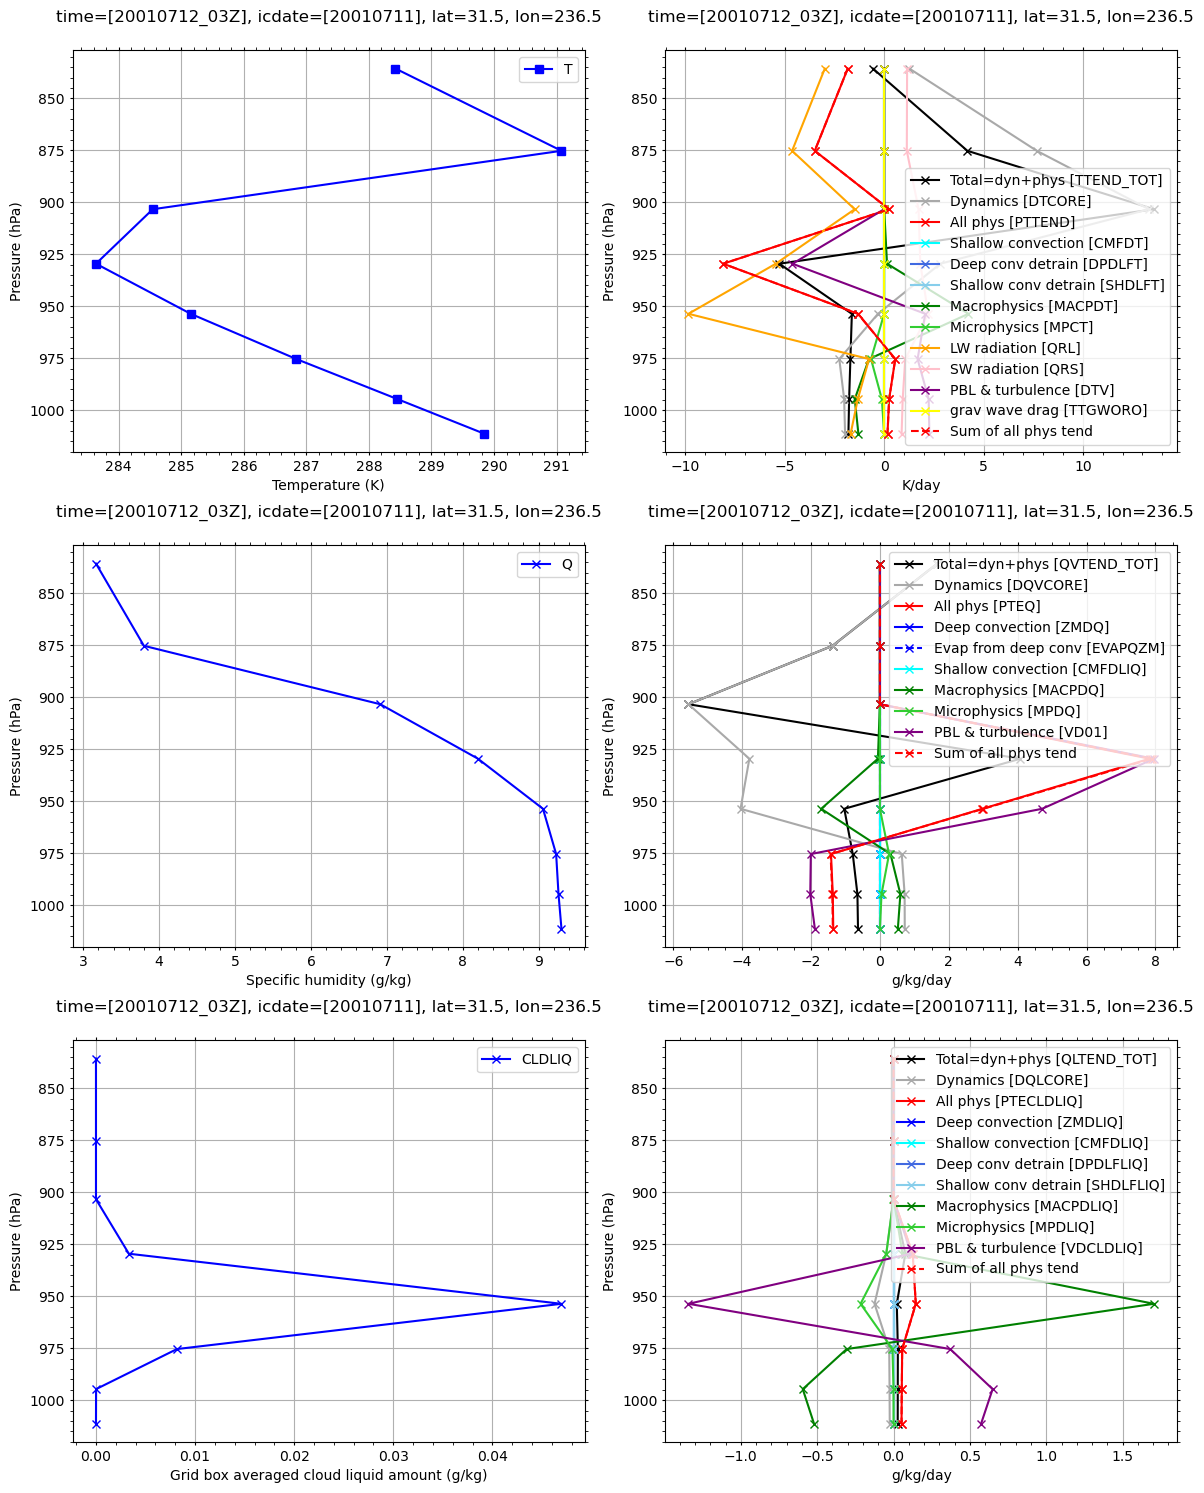

In [16]:
def plot_xy_profile_Nv_panel(icdate, date_selected, lat, lon,
                                var_group,
                               ):

    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate, lat=lat, lon=lon)
    
    play_pt = ds_state_latlon['play']

    title = f"time=[{date_selected}Z], icdate=[{icdate}], lat={lat}, lon={lon}"
    
    ds_dict = {
        "state": ds_state_latlon,
        "Ttend": ds_Ttend_latlon,
        "Qtend": ds_Qtend_latlon
    }

    #--- var list
    var_list_DT_budget = ['TTEND_TOT', 'DTCORE', 'PTTEND', 'CMFDT', 'DPDLFT', 
 'SHDLFT', 'MACPDT', 'MPDT', 'QRL', 'QRS', 'DTV', 'TTGWORO', 'DT_SUM_PHYS']

    var_list_DQ_budget = ['QVTEND_TOT', 'DQVCORE', 'PTEQ', 'ZMDQ', 'EVAPQZM', 'CMFDQ', 'MACPDQ', 'MPDQ', 'VD01', 'DQV_SUM_PHYS']

    var_list_DQL_budget = [
        'QLTEND_TOT', 'DQLCORE', 'PTECLDLIQ', 'ZMDLIQ', 'CMFDLIQ', 
        'DPDLFLIQ', 'SHDLFLIQ', 'MACPDLIQ', 'MPDLIQ', 'VDCLDLIQ', 'DQL_SUM_PHYS'
    ]

    var_list_dqi_budget = [
        'QITEND_TOT', 'DQICORE', 'PTECLDICE', 'ZMDICE', 'CMFDICE', 
        'DPDLFICE', 'SHDLFICE', 'MACPDICE', 'MPDICE', 'VDCLDICE', 'DQI_SUM_PHYS'
    ]    

    #--- set var_group
    if (var_group == "T_Q_QL_tend"):
        var_list = [
            ("state", ["T"]),
            ("Ttend", var_list_DT_budget),
            ("state", ["Q"]),
            ("Qtend", var_list_DQ_budget),
            ("state", ["CLDLIQ"]),
            ("Qtend", var_list_DQL_budget),
        ]
        
    elif (var_group == "test"):
        var_list = [ 
            ("state", ["T"]),
            ("Ttend", ["TTEND_TOT", "DTCORE", "PTTEND"]),  
            ("Ttend", ["QRL", "QRS", "MPDT"]),  
            ("state", ["Q"]),
            ]
    
    plot_xy_panel(ds_dict, var_list, play_pt, date_selected, title=title)    

#-----------
# do_test
#-----------

do_test="111"
if (do_test == "111"):
    icdate = "20010711"
    lat=31.5 ;  lon=236.5
    date_selected = "20010712_03"

    #var_group = "state"
    var_group = "T_Q_QL_tend"
    #var_group = "test"
    plot_xy_profile_Nv_panel(icdate, date_selected, lat, lon,
                                var_group,
                               )

## ----- xy_profile: N time steps, 1 variable -----

In [33]:
import xarray as xr
import cftime

###############
###############
###############
def select_ds_time_period(ds, start_str, end_str):
    """
    Selects data from an xarray Dataset within a specified time period.

    Parameters:
        ds (xarray.Dataset): The dataset with time in cftime.DatetimeNoLeap format.
        start_str (str): Start time in "YYYYDDMM_HH" format.
        end_str (str): End time in "YYYYDDMM_HH" format.

    Returns:
        xarray.Dataset: The selected dataset within the time range.
    """
    # Parse input strings
    start_time = cftime.DatetimeNoLeap(
        int(start_str[:4]),  # Year
        int(start_str[4:6]),  # Day
        int(start_str[6:8]),  # Month
        int(start_str[9:11])  # Hour
    )
    end_time = cftime.DatetimeNoLeap(
        int(end_str[:4]),  # Year
        int(end_str[4:6]),  # Day
        int(end_str[6:8]),  # Month
        int(end_str[9:11])  # Hour
    )

    # Select time range
    return ds.sel(time=slice(start_time, end_time))

###############
###############
###############
def get_ds_play_for_xy_profile_1vNt(ds: xr.Dataset, play: xr.DataArray, pmin=800, pmax=1100, start_str=None, end_str=None):
    """
    Selects a subset of an xarray Dataset and DataArray based on time and pressure level range.

    Parameters:
        ds (xr.Dataset): The input dataset with a time dimension in cftime.DatetimeNoLeap format.
        play (xr.DataArray): The input data array with the same time and lev dimensions as ds.
        pmin (int, optional): Minimum pressure level to filter (default: 800).
        pmax (int, optional): Maximum pressure level to filter (default: 1100).
        start_str (str, optional): Start time in "YYYYDDMM_HH" format.
        end_str (str, optional): End time in "YYYYDDMM_HH" format.

    Returns:
        Tuple[xr.Dataset, xr.DataArray]: The subset of the dataset and data array.
    """

    # Get dataset time range
    time_min, time_max = ds.time.min().item(), ds.time.max().item()

    # Convert input times if provided
    if start_str:
        start_time = cftime.DatetimeNoLeap(
            int(start_str[:4]), int(start_str[4:6]), int(start_str[6:8]), int(start_str[9:11])
        )
        if start_time < time_min or start_time > time_max:
            raise ValueError(f"start_str ({start_str}) is out of range: {time_min} to {time_max}")

    if end_str:
        end_time = cftime.DatetimeNoLeap(
            int(end_str[:4]), int(end_str[4:6]), int(end_str[6:8]), int(end_str[9:11])
        )
        if end_time < time_min or end_time > time_max:
            raise ValueError(f"end_str ({end_str}) is out of range: {time_min} to {time_max}")    
    
    # Select time range
    if start_str and end_str:
        ds = ds.sel(time=slice(start_time, end_time))
        play = play.sel(time=slice(start_time, end_time))

    # Filter by pressure level
    if "lev" in ds.dims or "lev" in ds.coords:
        ds = ds.sel(lev=(ds.lev >= pmin) & (ds.lev <= pmax))
            
    if "lev" in play.dims or "lev" in play.coords:
        play = play.sel(lev=(play.lev >= pmin) & (play.lev <= pmax))

    return ds, play

#-----------
# do_test
#-----------
do_test="111"

if (do_test == "111"):

    icdate = "20010709"
    lat=31.5 ;  lon=236.5
    
    ### read data
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate, lat=lat, lon=lon)
    play_pt = ds_state_latlon['play']

    ds_nt_np, play_nt_np = get_ds_play_for_xy_profile_1vNt(ds_state_latlon, play_pt)

    start_str="20010709_00" ;  end_str="20010712_00"    
    ds_nt_np, play_nt_np = get_ds_play_for_xy_profile_1vNt(ds_state_latlon, play_pt, start_str=start_str, end_str=end_str)

#ds_nt_np
#play_nt_np

<xarray.DataArray 'play' (time: 25, lev: 8)>
dask.array<getitem, shape=(25, 8), dtype=float64, chunksize=(8, 8), chunktype=numpy.ndarray>
Coordinates:
  * lev      (lev) float64 820.9 859.5 887.0 912.6 936.2 957.5 976.3 992.6
  * time     (time) object 2001-07-09 00:00:00 ... 2001-07-12 00:00:00
    lat      float64 31.57
    lon      float64 236.2
Attributes:
    long_name:  Pressure at layer midpoints
    units:      hPa

In [ ]:
###############
###############
###############
def get_ds_play_for_xy_profile_1vNt(ds: xr.Dataset, play, pmin=800, pmax=1100):
    
    # Step 1: Select the variables at the selected time step (based on date_selected)
    ds_1t = select_data_by_date(ds, date_selected)  # Select the data from the dataset based on the date
    var_1t = ds_1t[var_name]  # Extract the variable from the dataset
    var_1t = yhc.unit_convert(var_1t)  # Convert units of the variable (e.g., pressure, temperature)

    play_1t = select_data_by_date(play, date_selected)  # Select the play variable data for the selected date

    # Step 2: Select the data within the specified pressure range
    var_1t_np = var_1t.sel(lev=(var_1t.lev >= pmin) & (var_1t.lev <= pmax))  # Apply the pressure selection for the variable
    #ds_1t_np = ds_1t.sel(lev=(ds_1t.lev >= pmin) & (ds_1t.lev <= pmax))  # Apply the pressure selection for the variable
    play_1t_np = play_1t.sel(lev=(play_1t.lev >= pmin) & (play_1t.lev <= pmax))  # Apply the pressure selection for the play variable

    # Step 3: Return the selected variable and play variable within the pressure range
    return var_1t_np, play_1t_np

#-----------
# do_test
#-----------
do_test="112"

if (do_test == "111"):

    icdate = "20010709"
    lat=31.5 ;  lon=236.5
    
    ### read data
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate, lat=lat, lon=lon)
    play_pt = ds_state_latlon['play']
    
    date_selected = "20010710_03"
    var_name = ["Q"]
    var_1t_np, play_1t_np = get_var_play_for_xy_pv_plots (ds_state_latlon, play_pt, date_selected, var_name)

# Plot

## set icdate and lat/lon

In [31]:
## Only support icdate=0704~0711 in  ~/data/data.TaiESM1_hindcast/data.TaiESM1.July2001_hindcast02/run, 

icdate = "20010709"
lat=31.5 ;  lon=236.5

#lat=30 ;  lon=20   # Sahara
#lat=0; lon=180 ; # equator
#lat = 85 ; lon=320 # greenland

## Plot T

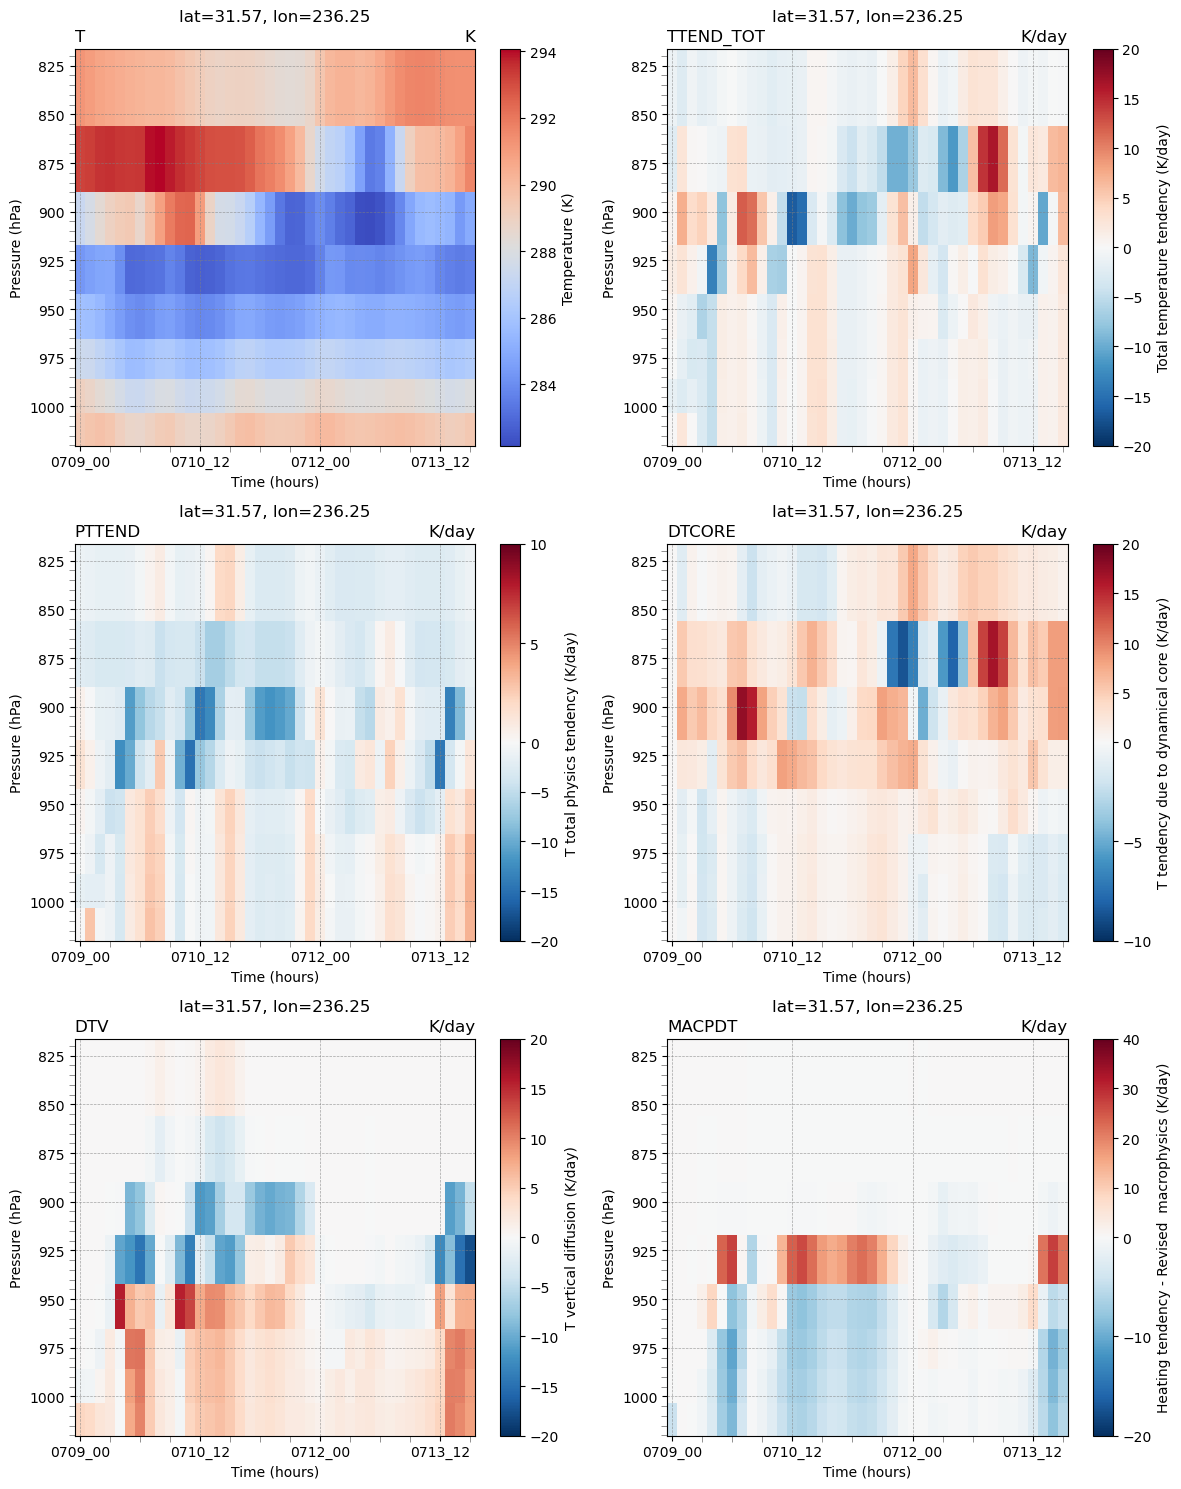

In [32]:
plot_time_lev_contour_panel(icdate, lat, lon, var_group="T")

## Plot QV

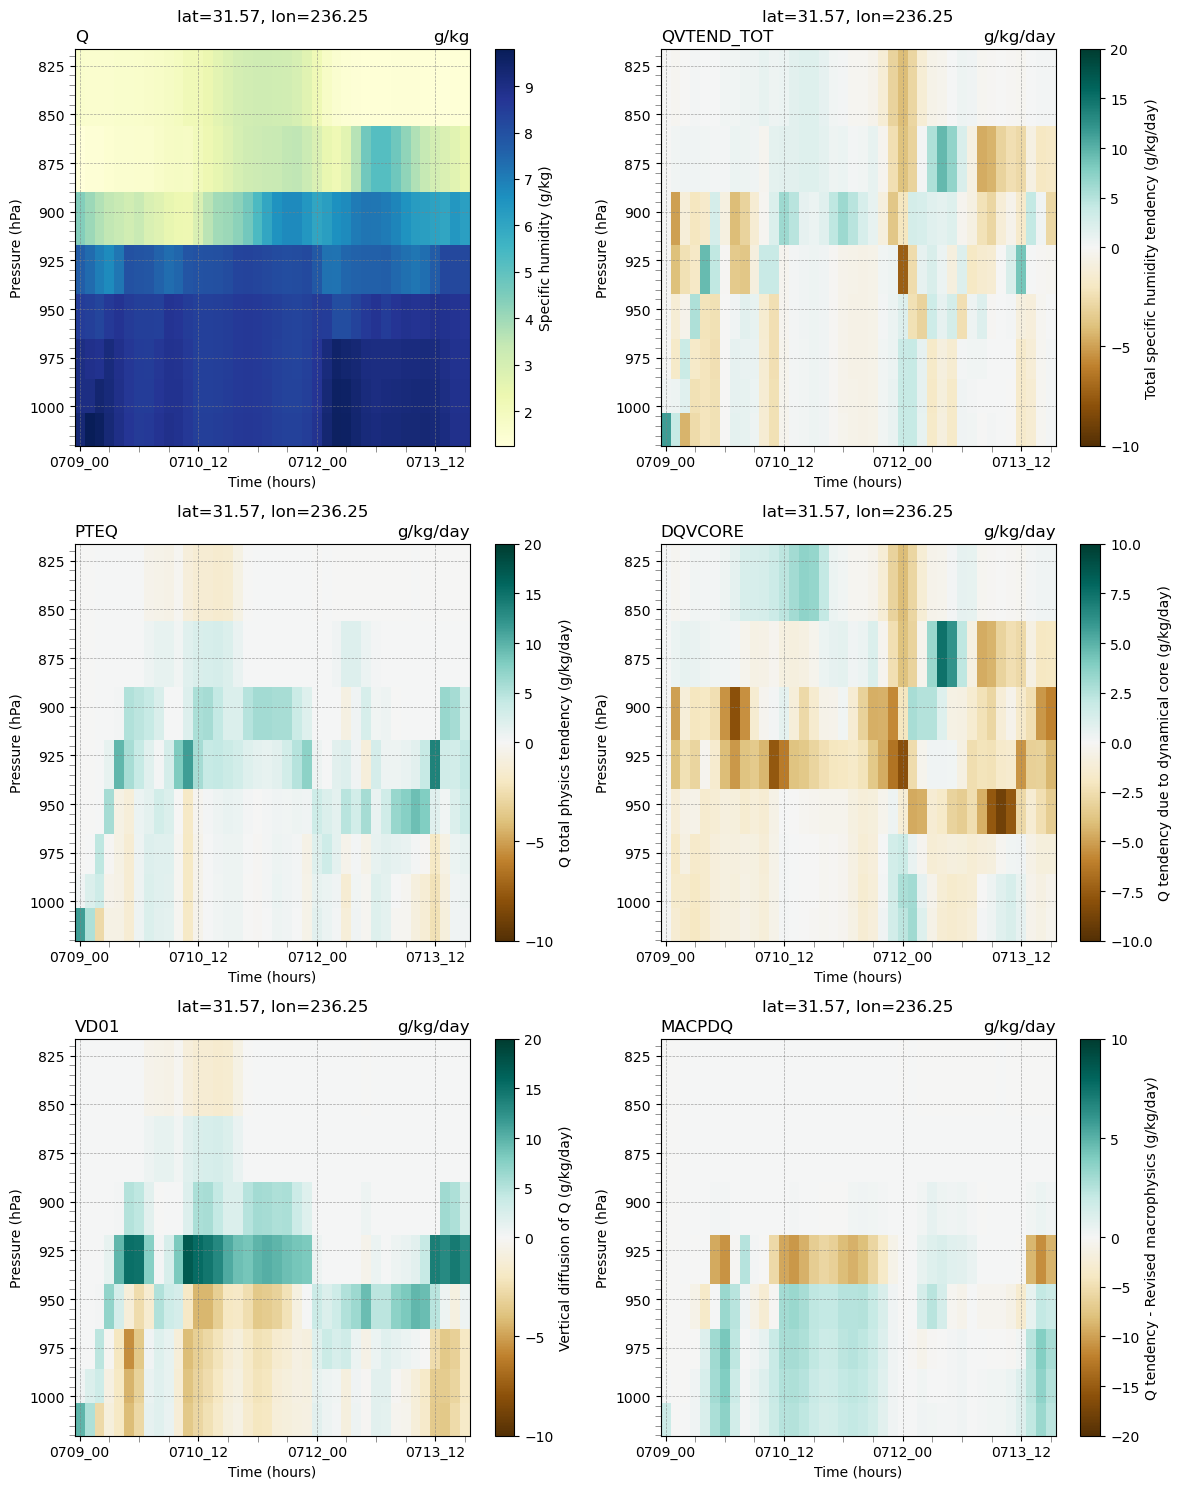

In [33]:
plot_time_lev_contour_panel(icdate, lat, lon, var_group="QV")

## Plot QL

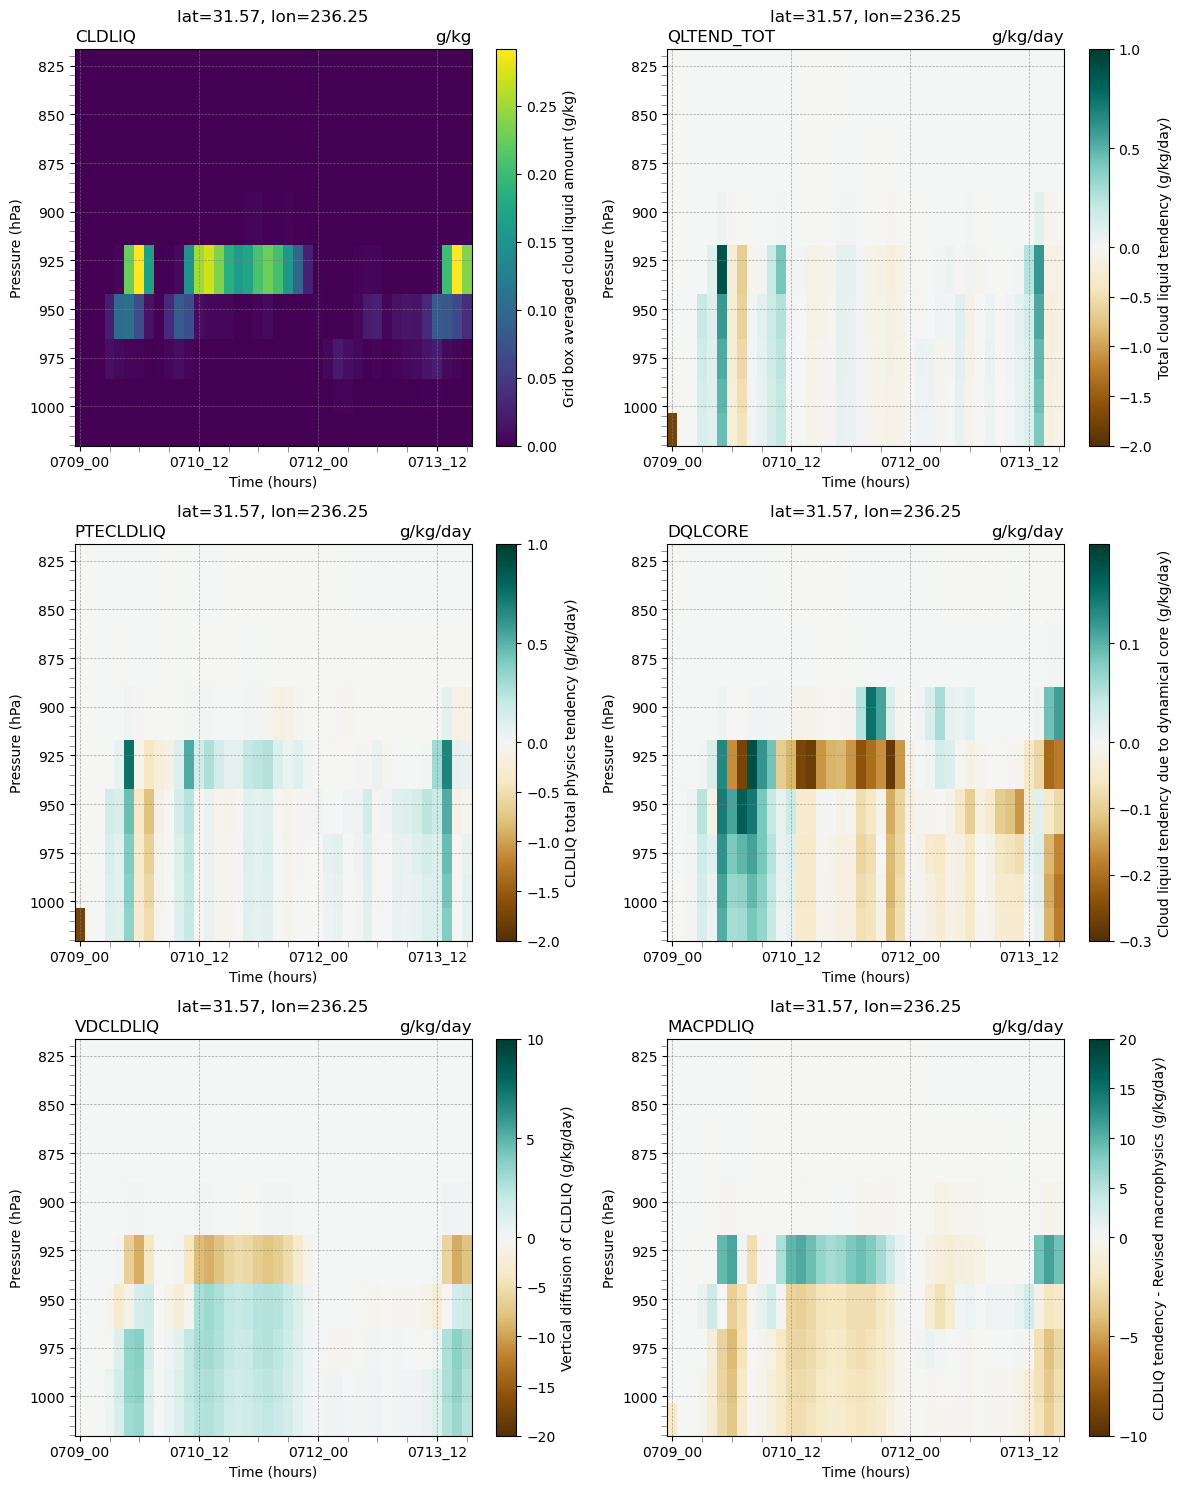

In [34]:
plot_time_lev_contour_panel(icdate, lat, lon, var_group="QL")